In [ ]:
import os
from pathlib import Path

import cv2
import numpy as np
import pandas as pd

BASE_DIR = Path("./animal_face_images")
TEST_DIR = Path("./test_images")

IMG_SIZE = 64

LABEL_MAP = {
    "강아지상": 0,
    "고양이상": 1,
    "여우상": 2
}

LABEL_NAME = {value: key for key, value in LABEL_MAP.items()}

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

print("설정 완료")
print(f"학습 데이터 경로: {BASE_DIR.resolve()}")
print(f"판별용 데이터 경로: {TEST_DIR.resolve()}")

def read_image_cv2(image_path):
    img_array = np.fromfile(str(image_path), np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    return img

def preprocess_face(image_path):
    img = read_image_cv2(image_path)

    if img is None:
        return None

    img = cv2.resize(img, (300, 300), interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.2,
        minNeighbors=4,
        minSize=(50, 50)
    )

    if len(faces) > 0:
        x, y, w, h = faces[0]
        cropped_face = gray[y:y+h, x:x+w]
    else:
        cropped_face = gray

    resized_face = cv2.resize(
        cropped_face,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_AREA
    )

    return resized_face.flatten()

flattened_data = []
labels = []

if not BASE_DIR.exists():
    raise FileNotFoundError("animal_face_images 폴더가 없습니다.")

for folder_name, label_value in LABEL_MAP.items():
    folder_path = BASE_DIR / folder_name

    if not folder_path.exists():
        print(f"{folder_name} 폴더 없음")
        continue

    for filename in os.listdir(folder_path):
        if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        img_path = folder_path / filename
        vector = preprocess_face(img_path)

        if vector is None:
            continue

        flattened_data.append(vector)
        labels.append(label_value)

if len(flattened_data) == 0:
    raise ValueError("학습 이미지가 없습니다. animal_face_images 폴더를 확인하세요.")

pixel_cols = [f"pixel_{i}" for i in range(IMG_SIZE * IMG_SIZE)]

df = pd.DataFrame(flattened_data, columns=pixel_cols)
df["Label"] = labels

df.to_csv(
    "./animal_face_dataset.csv",
    index=False,
    encoding="utf-8-sig"
)

print("animal_face_dataset.csv 생성 완료")
print(df["Label"].map(LABEL_NAME).value_counts())

test_vectors = []
test_files = []

if TEST_DIR.exists():
    for filename in os.listdir(TEST_DIR):
        if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        img_path = TEST_DIR / filename
        vector = preprocess_face(img_path)

        if vector is None:
            continue

        test_vectors.append(vector)
        test_files.append(filename)

    if len(test_vectors) > 0:
        df_test = pd.DataFrame(test_vectors, columns=pixel_cols)
        df_test["Origin_Filename"] = test_files

        df_test.to_csv(
            "./unseen_test_dataset.csv",
            index=False,
            encoding="utf-8-sig"
        )

        print("unseen_test_dataset.csv 생성 완료")
    else:
        print("test_images 안에 처리 가능한 이미지가 없습니다.")
else:
    print("test_images 폴더가 없습니다.")
    

설정 완료
학습 데이터 경로: /Users/chaewon/Desktop/26-1/AI개론/TeamProject/AI_Team5-main/animal_face_images
판별용 데이터 경로: /Users/chaewon/Desktop/26-1/AI개론/TeamProject/AI_Team5-main/test_images
animal_face_dataset.csv 생성 완료
Label
강아지상    34
고양이상    32
여우상     32
Name: count, dtype: int64
unseen_test_dataset.csv 생성 완료


/Users/chaewon/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chaewon/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50500 (\N{HANGUL SYLLABLE A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chaewon/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chaewon/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


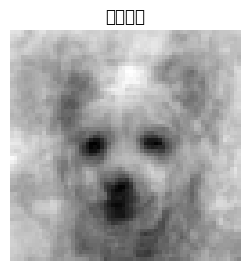

/Users/chaewon/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chaewon/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chaewon/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


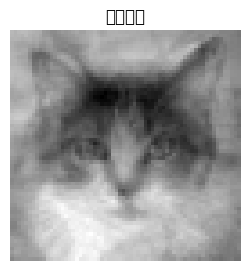

/Users/chaewon/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chaewon/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


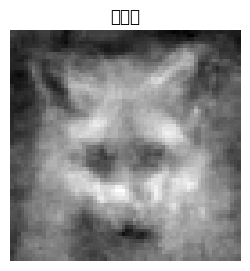


템플릿 매칭 1차 정확도
Accuracy : 0.7500

Confusion Matrix
[[4 2 1]
 [0 6 1]
 [0 1 5]]

Classification Report
              precision    recall  f1-score   support

        강아지상       1.00      0.57      0.73         7
        고양이상       0.67      0.86      0.75         7
         여우상       0.71      0.83      0.77         6

    accuracy                           0.75        20
   macro avg       0.79      0.75      0.75        20
weighted avg       0.80      0.75      0.75        20



In [ ]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

IMG_SIZE = 64

LABEL_NAME = {
    0: "강아지상",
    1: "고양이상",
    2: "여우상",
    3: "곰상",
    4: "토끼상"
}

DATASET_PATH = Path("./animal_face_dataset.csv")

if not DATASET_PATH.exists():
    raise FileNotFoundError("animal_face_dataset.csv가 없습니다. 먼저 1단계 전처리 셀을 실행하세요.")

df = pd.read_csv(DATASET_PATH)

pixel_cols = [col for col in df.columns if col.startswith("pixel_")]

X = df[pixel_cols].values / 255.0
y = df["Label"].values

existing_labels = sorted(df["Label"].unique())
existing_label_names = [LABEL_NAME[label] for label in existing_labels]

class_counts = pd.Series(y).value_counts()
can_stratify = (class_counts >= 2).all()

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y if can_stratify else None
)

templates = {}

for label in existing_labels:
    class_images = X_train[y_train == label]
    templates[label] = class_images.mean(axis=0)

for label in existing_labels:
    plt.figure(figsize=(3, 3))
    plt.imshow(
        templates[label].reshape(IMG_SIZE, IMG_SIZE),
        cmap="gray"
    )
    plt.title(LABEL_NAME[label])
    plt.axis("off")
    plt.show()

def predict_template_matching(image, templates):
    """
    입력 이미지와 각 동물상 평균 얼굴 템플릿 사이의
    유클리디안 거리를 계산한 뒤 가장 가까운 라벨을 반환합니다.
    """
    distances = {}

    for label, template in templates.items():
        distance = np.linalg.norm(image - template)
        distances[label] = distance

    pred_label = min(distances, key=distances.get)

    return pred_label, distances


y_pred = []

for image in X_val:
    pred_label, distances = predict_template_matching(image, templates)
    y_pred.append(pred_label)

accuracy = accuracy_score(y_val, y_pred)

print("\n템플릿 매칭 1차 정확도")
print(f"Accuracy : {accuracy:.4f}")

print("\nConfusion Matrix")
print(
    confusion_matrix(
        y_val,
        y_pred,
        labels=existing_labels
    )
)

print("\nClassification Report")
print(
    classification_report(
        y_val,
        y_pred,
        labels=existing_labels,
        target_names=existing_label_names,
        zero_division=0
    )
)


In [ ]:
df_test = pd.read_csv("./unseen_test_dataset.csv")

X_test = df_test[pixel_cols].values / 255.0
file_names = df_test["Origin_Filename"].values

results = []

for filename, x in zip(file_names, X_test):
    pred_label, distances = predict_template_matching(
    x,
    templates
)

    result = {
        "filename": filename,
        "pred_label": pred_label,
        "pred_animal": LABEL_NAME.get(pred_label, str(pred_label))
    }

    for label, dist in distances.items():
        result[f"distance_{LABEL_NAME.get(label, label)}"] = dist

    results.append(result)

df_result = pd.DataFrame(results)
df_result.to_csv("./template_matching_result.csv", index=False, encoding="utf-8-sig")

df_result.head()


,filename,pred_label,pred_animal,distance_강아지상,distance_고양이상,distance_여우상
0,Al_Gore_0005.jpg,0,강아지상,11.723246,16.325343,13.971722
1,Colin_Farrell_0005.jpg,0,강아지상,9.557493,12.586669,10.724718
2,Colin_Farrell_0004.jpg,0,강아지상,10.954061,14.899908,11.296881
3,Al_Gore_0004.jpg,0,강아지상,8.563522,13.862065,11.290627
4,Chanda_Rubin_0005.jpg,1,고양이상,17.532303,14.210291,15.812392


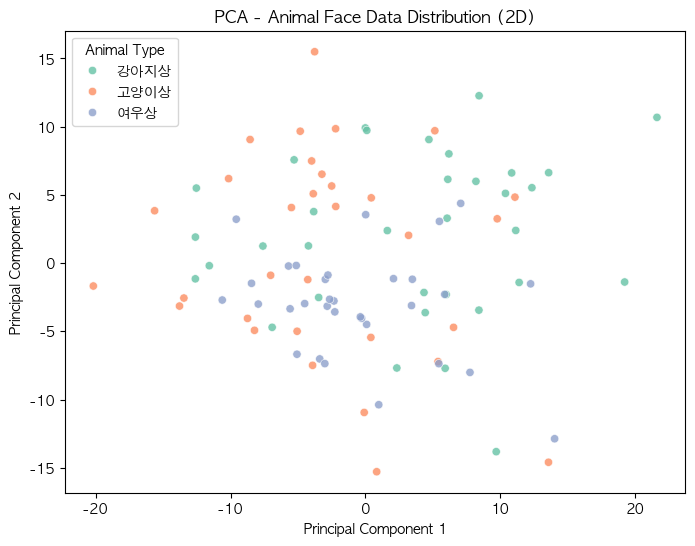

--- Random Forest 예측 결과 ---
[Al_Gore_0005.jpg] -> 예측: 강아지상 | (강아지상: 75.0%, 고양이상: 3.0%, 여우상: 22.0%)
[Colin_Farrell_0005.jpg] -> 예측: 여우상 | (강아지상: 26.0%, 고양이상: 16.0%, 여우상: 58.0%)
[Colin_Farrell_0004.jpg] -> 예측: 강아지상 | (강아지상: 73.0%, 고양이상: 2.0%, 여우상: 25.0%)
[Al_Gore_0004.jpg] -> 예측: 강아지상 | (강아지상: 72.0%, 고양이상: 9.0%, 여우상: 19.0%)
[Chanda_Rubin_0005.jpg] -> 예측: 강아지상 | (강아지상: 66.0%, 고양이상: 9.0%, 여우상: 25.0%)
[Colin_Farrell_0006.jpg] -> 예측: 고양이상 | (강아지상: 18.0%, 고양이상: 68.0%, 여우상: 14.0%)
[Chanda_Rubin_0004.jpg] -> 예측: 강아지상 | (강아지상: 42.0%, 고양이상: 26.0%, 여우상: 32.0%)
[Colin_Farrell_0002.jpg] -> 예측: 여우상 | (강아지상: 17.0%, 고양이상: 3.0%, 여우상: 80.0%)
[Chanda_Rubin_0001.jpg] -> 예측: 여우상 | (강아지상: 35.0%, 고양이상: 5.0%, 여우상: 60.0%)
[Al_Gore_0002.jpg] -> 예측: 여우상 | (강아지상: 26.0%, 고양이상: 33.0%, 여우상: 41.0%)
[Chanda_Rubin_0003.jpg] -> 예측: 강아지상 | (강아지상: 52.0%, 고양이상: 13.0%, 여우상: 35.0%)
[Colin_Farrell_0001.jpg] -> 예측: 강아지상 | (강아지상: 62.0%, 고양이상: 15.0%, 여우상: 23.0%)
[Chanda_Rubin_0002.jpg] -> 예측: 강아지상 | (강아지상: 51.0%, 고양이상: 15.0%, 여우상

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier  # 또는 SVM의 SVC
from sklearn.metrics import classification_report, confusion_matrix

plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

df_train = pd.read_csv("./animal_face_dataset.csv")
df_test = pd.read_csv("./unseen_test_dataset.csv")

pixel_cols = [col for col in df_train.columns if col not in ["Label", "Origin_Filename"]]

# 픽셀 데이터 정규화 (0~1 사이 값)
X_train = df_train[pixel_cols].values / 255.0
y_train = df_train["Label"].values  # 문자열 라벨 또는 인코딩된 라벨
X_test = df_test[pixel_cols].values / 255.0

name_map = {0: "강아지상", 1: "고양이상", 2: "여우상"}
cluster_map = {0: "강아지상(예측)", 1: "고양이상(예측)", 2: "여우상(예측)"}

# PCA 차원 축소 및 시각화
# 1. 2차원으로 축소하는 PCA 객체 생성 및 학습
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# y_train 배열 안에 들어있는 숫자(0, 1, 2)를 name_map을 이용해 한글 리스트로 미리 변환
y_train_kor = [name_map.get(int(val), f"{val}상") for val in y_train]

# 2. PCA 시각화 (산점도)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_train_pca[:, 0],
    y=X_train_pca[:, 1],
    hue=y_train_kor,
    palette="Set2",
    alpha=0.8,
)

plt.title("PCA - Animal Face Data Distribution (2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Animal Type")
plt.show()

# 머신러닝 모델 학습 (Random Forest 예시)
# 기획서 상의 "각 동물상에 속할 확률 도출" 기능 구현
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_pca, y_train)  # PCA로 축소된 데이터로 학습

# 테스트 데이터 예측 및 확률 도출
test_predictions = rf_model.predict(X_test_pca)
test_probabilities = rf_model.predict_proba(X_test_pca)

print("--- Random Forest 예측 결과 ---")
for i, filename in enumerate(df_test["Origin_Filename"]):
    # 1. 모델이 예측한 숫자(0, 1, 2)를 딕셔너리를 거쳐 "강아지상", "고양이상" 등의 한글로 변환
    pred_num = test_predictions[i]
    pred_animal = name_map.get(int(pred_num), f"{pred_num}상")
    
    # 2. 확률 목록의 숫자(0, 1, 2)들도 전부 한글 이름으로 치환하여 문자열로 만들기
    prob_list = []
    for cls, prob in zip(rf_model.classes_, test_probabilities[i]):
        kor_cls_name = name_map.get(int(cls), f"{cls}상")  # 숫자를 한글로 변환!
        prob_list.append(f"{kor_cls_name}: {prob*100:.1f}%")
    prob_str = ", ".join(prob_list)

    # 최종 결과 출력
    print(f"[{filename}] -> 예측: {pred_animal} | ({prob_str})")

# 비지도 학습 K-means 군집화 및 타당성 분석
# 동물상 종류 개수(예: 강아지, 고양이, 여우 = 3개)로 군집화
n_animals = len(df_train["Label"].unique())
kmeans = KMeans(n_clusters=n_animals, random_state=42)
cluster_labels = kmeans.fit_predict(X_train_pca)

# 실제 라벨과 교차 테이블(Cross-tabulation)을 만들어 타당성 분석
df_analysis = pd.DataFrame({"Actual_Label": y_train, "Cluster_ID": cluster_labels})

# 실제 정답 라벨(숫자)을 한글로 변경
df_analysis["Actual_Label_Name"] = df_analysis["Actual_Label"].map(name_map)

# 데이터프레임의 Cluster_ID 컬럼을 숫자가 아닌 동물이름으로 일치시키기
df_analysis["Cluster_Name"] = df_analysis["Cluster_ID"].map(cluster_map)

cross_tab = pd.crosstab(df_analysis["Actual_Label"], df_analysis["Cluster_Name"])

print("\n--- K-means 군집과 실제 동물상 라벨 매칭 타당성 분석 ---")
print(cross_tab)